# Smart Customer-Service Intake — one process, four ways

**Author: Peter Mathews** · A teaching artifact for the AI Coach role.

A single business process — *triage an inbound customer-service ticket and route
it* — implemented four ways, from a keyword script to a Claude-powered agent,
and compared on accuracy, cost, and capability.

This is built the way I'd coach a team: pick a real process, map the people /
process / technology, then implement it at increasing levels of sophistication
and **make the team defend, with numbers, which one actually fits.** Knowing
*when* a rule beats ML beats GenAI is the judgment a coach has to teach — so the
repo is organized around that decision, not around any one model.

| Approach | Stack | What it shows |
| --- | --- | --- |
| **A. Rules** | Python, regex | The honest baseline you must beat |
| **B. Classic ML** | pandas, scikit-learn (incl. a neural net) | Learned classification, real metrics |
| **C. GenAI** | Claude API, structured output | Zero-shot classification + extraction |
| **D. Agent** | LangGraph + Claude | Conditional routing on intent & attachments |


## 1 · The business process (People · Process · Technology)

Before any model, map the current state. Every "AI project" is really a process
with people and tools around it — the model is one box.

| Layer | Current state (a typical support org) |
| --- | --- |
| **People** | Tier-1 agents read each ticket, guess the right queue, manually pull order info from attachments, escalate angry customers by feel. |
| **Process** | Inbound ticket → read → classify intent → check sentiment/priority → if a receipt/photo is attached, open it and extract details → route to a team → take an action. |
| **Technology** | A shared inbox + a ticketing tool. Routing is human judgment; nothing is measured. |

**The transformation question:** which parts of that process should become a
rule, a trained model, an LLM call, or an agent — and what does each cost?

> **Coach's Note.** Notice we wrote the process down *before* touching a model.
> Half the value a team delivers is realizing a step doesn't need ML at all.


In [1]:
# --- setup -------------------------------------------------------------
# Local: run from the repo's notebooks/ folder.
# Colab:  !git clone <your-repo-url> && %cd <repo> ; then sys.path to 'src'
import os, sys
SRC = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if not os.path.isdir(SRC):                      # fallback for Colab/flat layouts
    SRC = os.path.abspath("src")
sys.path.insert(0, SRC)

import warnings; warnings.filterwarnings("ignore")
import pandas as pd
from sklearn.model_selection import train_test_split

from approach_b_ml import load_data
df = load_data()
print(f"{len(df)} tickets loaded")
df.head(3)


240 tickets loaded


,id,text,intent,sentiment,attachment_type,attachment_content
0,T0089,"I can't get the export feature to work, it jus...",technical_issue,neutral,none,
1,T0178,I'm locked out of my account and the reset ema...,account_access,negative,none,
2,T0187,Good morning. This is the third time I've cont...,complaint,negative,none,


## 2 · A quick look at the data (EDA)

The dataset is a labelled set of customer-service tickets — some with an
attached receipt (a document) or photo (an image). It's **synthetic on
purpose**: real ticket queues are proprietary (the exact reason this kind of
public demo exists). Swapping in a real public dataset like HuggingFace
`banking77` is a one-cell change.


In [2]:
# Class balance and how many tickets carry an attachment.
print("Tickets per intent:")
print(df["intent"].value_counts().to_string())
print("\nSentiment mix:", df["sentiment"].value_counts().to_dict())
print("Attachments:", df["attachment_type"].value_counts().to_dict())


Tickets per intent:
intent
technical_issue     30
account_access      30
complaint           30
billing_question    30
refund_request      30
order_status        30
damaged_product     30
general_inquiry     30

Sentiment mix: {'neutral': 133, 'negative': 97, 'positive': 10}
Attachments: {'none': 195, 'image': 23, 'document': 22}


In [3]:
# What a few tickets actually look like — including one with a receipt.
for _, r in df[df.attachment_type == "document"].head(1).iterrows():
    print("TICKET:", r.text)
    print("ATTACHED DOCUMENT:\n", r.attachment_content)


TICKET: Good morning. I was billed twice, please refund order A29410.
ATTACHED DOCUMENT:
 ORDER CONFIRMATION
Order #: A29410
Date: 2026-01-19
Item: Wireless Headphones
Total: $113.98
Thank you for your purchase!


In [4]:
# One train/test split, reused by every approach so the comparison is fair.
train, test = train_test_split(df, test_size=0.3, random_state=42, stratify=df["intent"])
print(f"train={len(train)}  test={len(test)}")


train=168  test=72


## 3 · Approach A — Rules / regex (the "before")

Keyword lexicons for intent, a word list for sentiment, regex for the receipt.
This is where most teams genuinely start. It's instant and free and fully
explainable — and it breaks the moment a customer phrases things in a way nobody
added to the keyword list.


In [5]:
import approach_a_rules as rules
from evaluate import evaluate_offline

sample = "Hi team, my order A12345 arrived cracked, photo attached. Pretty upset."
print(rules.triage(sample, "image", "photo_damaged").to_dict())

m = evaluate_offline(test, rules.triage)
print(f"\nrules → intent {m['intent_acc']:.1%} | sentiment {m['sentiment_acc']:.1%} "
      f"| {m['latency_ms']:.3f} ms/ticket")


{'intent': 'damaged_product', 'sentiment': 'neutral', 'priority': 'normal', 'route': 'Returns & Quality', 'action': 'Inspect photo, open return, send replacement', 'extracted': {'order_id': None, 'amount': None, 'order_date': None}, 'image_label': 'damaged'}

rules → intent 81.9% | sentiment 47.2% | 0.013 ms/ticket


> **Coach's Note.** The rules score is the bar. If a trained model can't beat
> a morning's worth of keywords, it isn't worth the complexity — make the team
> prove the lift.


## 4 · Approach B — Classic ML (scikit-learn)

Learn intent and sentiment from labelled data. Two models on the *same*
pipeline, so students see how `scikit-learn` composes: TF-IDF → classifier.
- **LogisticRegression** — the strong, cheap baseline.
- **MLPClassifier** — a small **neural network** (one of the four ML concepts).


In [6]:
from approach_b_ml import MLTriager

for model in ("logreg", "mlp"):
    t = MLTriager(intent_model=model, sentiment_model=model).fit(train)
    m = evaluate_offline(test, t.triage)
    print(f"{model:7s} → intent {m['intent_acc']:.1%} | sentiment {m['sentiment_acc']:.1%}")


logreg  → intent 95.8% | sentiment 59.7%


mlp     → intent 100.0% | sentiment 48.6%


> **Coach's Note.** The neural net is *not* automatically better — on a small
> dataset it's higher-variance and can trail the linear baseline on the harder
> label (sentiment). "Use the deep model" is a decision to justify, not a
> default. This is exactly the kind of result I'd have a team explain.


### 4b · Image classification mini-lesson

When the attachment is a **photo**, you need to look at pixels, not text — image
classification, the fourth required ML concept. Real product photos need a
labelled image set we can't ship, so this trains on scikit-learn's `digits`
(real 8×8 images) with the *exact* pipeline you'd use on photos: pixels → split
→ neural net → evaluate.


In [7]:
from image_classifier import train_image_classifier
_, img_acc = train_image_classifier()
print(f"Image classifier (digits stand-in) test accuracy: {img_acc:.1%}")


Image classifier (digits stand-in) test accuracy: 96.7%


## 5 · Approach C — GenAI with Claude (structured output)

One Claude call classifies intent + sentiment **and** extracts the receipt
fields in the same shot — zero-shot, no training data. `messages.parse()` with a
Pydantic schema guarantees valid structured output (no brittle JSON parsing),
and the model *tier* is a cost dial.

The cell below runs live if `ANTHROPIC_API_KEY` is set; otherwise it just shows
how. The code is [`src/approach_c_genai.py`](../src/approach_c_genai.py).


In [8]:
import os
if os.getenv("ANTHROPIC_API_KEY"):
    from approach_c_genai import GenAITriager
    t = GenAITriager(tier="haiku")
    receipt = ("ORDER CONFIRMATION\nOrder #: A55512\nDate: 2026-03-14\n"
               "Item: Wireless Headphones\nTotal: $129.99")
    out = t.triage("I want my money back, the headphones broke.", "document", receipt)
    print(out.to_dict())
    print("tokens (in, out):", t.last_usage)
else:
    print("Set ANTHROPIC_API_KEY to run Claude live.")
    print("The model reads the free-text ticket AND the receipt, returning a")
    print("validated TriageSchema — intent, sentiment, and extracted order fields.")


Set ANTHROPIC_API_KEY to run Claude live.
The model reads the free-text ticket AND the receipt, returning a
validated TriageSchema — intent, sentiment, and extracted order fields.


> **Coach's Note.** The receipt extraction is the tell. The regex approach only
> works because it knows the receipt's exact layout; change the format and it
> returns nothing. The LLM reads a receipt it has never seen. That capability —
> not raw accuracy — is what justifies the per-call cost.


## 6 · Approach D — Agentic workflow (LangGraph)

The same intake as a **graph that branches**. After classifying, the path
depends on intent *and* what's attached:

```
classify ─┬─ document → extract receipt fields ─┐
          ├─ image    → classify the photo ──────┤
          ├─ complaint+negative → escalate ──────┼─→ route + action
          └─ nothing  ───────────────────────────┘
```

That conditional routing — "depending on the action and whether there's an
attachment, take a different action" — is what an agent framework expresses
cleanly and a flat pipeline can't. Code: [`src/approach_d_agent.py`](../src/approach_d_agent.py).


In [9]:
import os
if os.getenv("ANTHROPIC_API_KEY"):
    try:
        from approach_d_agent import build_agent, triage as agent_triage
        agent = build_agent(model_tier="haiku")
        receipt = "ORDER CONFIRMATION\nOrder #: A55512\nDate: 2026-03-14\nTotal: $129.99"
        print(agent_triage(agent, "Please refund me, item never worked.", "document", receipt).to_dict())
    except ImportError:
        print("pip install langgraph langchain-anthropic to run the agent.")
else:
    print("Set ANTHROPIC_API_KEY (+ pip install langgraph langchain-anthropic) to run the agent.")
    print("The graph routes the receipt ticket through: classify → extract_doc → finalize.")


Set ANTHROPIC_API_KEY (+ pip install langgraph langchain-anthropic) to run the agent.
The graph routes the receipt ticket through: classify → extract_doc → finalize.


## 7 · The decision matrix — which approach actually fits?

This is the payoff. Same process, four implementations, on one table. The
offline rows are measured; the GenAI rows show cost from **real published
pricing** (Haiku \$1/\$5, Sonnet \$3/\$15, Opus \$5/\$25 per 1M tokens) and a
representative token count. Run `python src/evaluate.py --live` to fill in
measured GenAI accuracy too.


In [10]:
from evaluate import build_matrix
matrix = build_matrix(live=bool(os.getenv("ANTHROPIC_API_KEY")))
pd.set_option("display.max_columns", None)
matrix


,approach,intent_acc,sentiment_acc,doc_extract_acc,latency_ms,cost_per_1k_$,training_data,extraction,images,explainability
0,A. Rules / regex,0.819444,0.472222,1.0,0.027142,0.00,none,regex (brittle),filename only,total
1,B. ML — TF-IDF + LogReg,0.958333,0.597222,1.0,0.390549,0.00,needs labels,regex (brittle),needs labelled photos,medium
2,B. ML — neural net (MLP),1.000000,0.486111,1.0,0.413238,0.00,needs labels,regex (brittle),needs labelled photos,medium
3,C. GenAI — Claude haiku,NaN,NaN,NaN,NaN,0.37,none (zero-shot),"zero-shot, robust",vision-capable,low
4,C. GenAI — Claude sonnet,NaN,NaN,NaN,NaN,1.11,none (zero-shot),"zero-shot, robust",vision-capable,low
5,C. GenAI — Claude opus,NaN,NaN,NaN,NaN,1.85,none (zero-shot),"zero-shot, robust",vision-capable,low


## 7b · Where it runs & what it costs at scale (AWS · GCP · Azure)

Accuracy is half the decision; **where it runs and how it's billed** is the
other half — a cloud question. Each approach maps to a managed service, and the
cost *models* cross over. Full write-up: [`docs/deployment_and_cost.md`](../docs/deployment_and_cost.md).

| Approach | AWS | Google Cloud | Azure | Cost model |
| --- | --- | --- | --- | --- |
| Rules | Lambda | Cloud Functions | Azure Functions | per-invocation (≈ free) |
| Classic ML | SageMaker | Vertex AI | Azure ML | instance-hour **or** per-request |
| GenAI (Claude) | Bedrock | Vertex Model Garden | Azure AI Foundry | per-token; Batch ≈ 50% off |
| Agent | Bedrock / API+tools | Vertex Agent Builder | Azure AI Agent Service | tokens + orchestration |

Claude runs on **Bedrock, Vertex, Foundry, and the Anthropic API** — the same
`messages.parse()` code, just a different client + model-id string
([`src/providers.py`](../src/providers.py)). So provider choice is procurement
and compliance, not a rewrite.


In [11]:
from tco import build_tco_table
build_tco_table()


,approach,"$10,000/mo","$100,000/mo","$1,000,000/mo","$10,000,000/mo"
0,Rules → serverless (Lambda/Functions),0.0,0.04,0.4,4.0
1,Classic ML → provisioned endpoint,88.0,88.00,88.0,88.0
2,Classic ML → serverless inference,0.5,5.00,50.0,500.0
3,Claude Haiku (per-token),3.7,37.00,370.0,3700.0
4,Claude Sonnet (per-token),11.1,111.00,1110.0,11100.0
5,Claude Opus (per-token),18.5,185.00,1850.0,18500.0


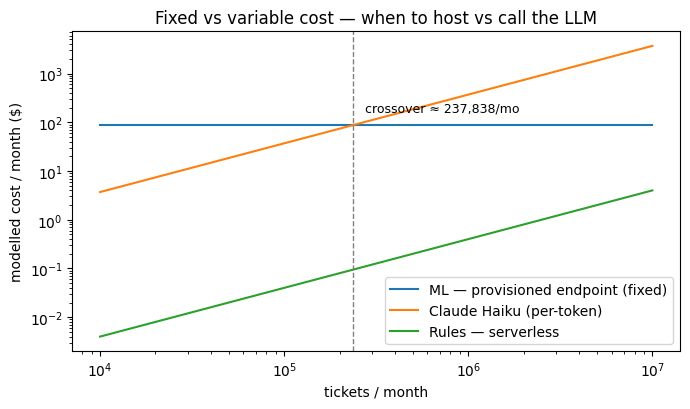

Below ~237,838 tickets/mo: call Haiku. Above: host the trained model.


In [12]:
# The crossover: fixed-cost endpoint vs variable-cost LLM.
import matplotlib.pyplot as plt
from tco import monthly_cost, crossover_volume, llm_cost_per_ticket, ML_ENDPOINT_MONTHLY

vols = [10_000 * (10 ** (i / 10)) for i in range(31)]  # 10k → 10M, log-spaced
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(vols, [monthly_cost("ml_endpoint", v) for v in vols], label="ML — provisioned endpoint (fixed)")
ax.plot(vols, [monthly_cost("genai_haiku", v) for v in vols], label="Claude Haiku (per-token)")
ax.plot(vols, [monthly_cost("rules_serverless", v) for v in vols], label="Rules — serverless")
xo = crossover_volume(ML_ENDPOINT_MONTHLY, llm_cost_per_ticket("haiku"))
ax.axvline(xo, color="grey", ls="--", lw=1)
ax.annotate(f"crossover ≈ {xo:,.0f}/mo", (xo, ML_ENDPOINT_MONTHLY), textcoords="offset points",
            xytext=(8, 10), fontsize=9)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("tickets / month"); ax.set_ylabel("modelled cost / month ($)")
ax.set_title("Fixed vs variable cost — when to host vs call the LLM")
ax.legend(); fig.tight_layout(); plt.show()
print(f"Below ~{xo:,.0f} tickets/mo: call Haiku. Above: host the trained model.")


> **Coach's Note.** The cheapest *per-call* option is often the most expensive
> to *own* — once you add training, labelling, endpoints, and maintenance (the
> TCO checklist in the doc). Making a team put a dollar figure on each row, and
> on the AWS/GCP service they'd actually deploy, is the coaching.


## 8 · So what would I tell the team?

There's no single winner — and saying so *is* the lesson:

- **Rules** win when the patterns are stable and the cost of a miss is low.
  Free, instant, auditable. Start here; keep them for the easy 60%.
- **Classic ML** wins on **high-volume, stable-label** classification once you
  have labelled data. Near-zero inference cost is decisive at a million tickets
  a month — but it can't read a new receipt format or a photo without a lot more
  labelled data, and it needs that data to exist at all.
- **GenAI** wins on the **long tail and on extraction** — new phrasings, reading
  documents and images zero-shot. It costs real money per call, so reserve it
  for where that flexibility pays: the messy cases and the attachments.
- **The agent** wins when the **process itself branches** — different actions for
  different intents and attachments. It's orchestration, not a smarter model.

**The pattern I'd actually ship:** rules and a cheap ML model handle the bulk
cheaply; route the ambiguous tickets and all attachments to a Haiku/agent path;
reserve Sonnet/Opus for the hardest cases. That blended design — not "use the
biggest model" — is the judgment this repo is meant to teach.

> **Coach's Note (the meta-point).** A Fellow team's instinct is "use the
> fanciest thing." My job is to make them build the boring baseline, measure the
> lift, and put a dollar figure on the difference — then choose. This notebook
> is the scaffold I'd reuse for that conversation on every project.
